In [1]:

# IMPLEMENTATION AND COMPARISON OF RNN, LSTM AND GRU
# FOR SEQUENCE CLASSIFICATION
#
# Dataset: IMDb 50K Movie Reviews
# Task: Binary Sentiment Classification
#
# Positive Review  : 1
# Negative Review  : 0


In [2]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    GRU,
    Dense,
    Dropout
)

# Evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Other utilities
import re
import time
import random

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [3]:
# Check whether TensorFlow can detect a GPU

print("Available GPUs:")

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    for gpu in gpus:
        print(gpu)

    print("\nGPU is available!")
else:
    print("No GPU detected.")
    print("The notebook will run on CPU.")

Available GPUs:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

GPU is available!


In [4]:
# Set random seeds so that our results are more reproducible

SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [5]:
from google.colab import files

uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset (1).csv


In [6]:
# Load the CSV file

df = pd.read_csv("IMDB Dataset.csv")

# Display dataset shape
print("Dataset shape:", df.shape)

# Display first 5 rows
df.head()

Dataset shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
# Display basic information about the dataset

print("Dataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None

Missing values:
review       0
sentiment    0
dtype: int64

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


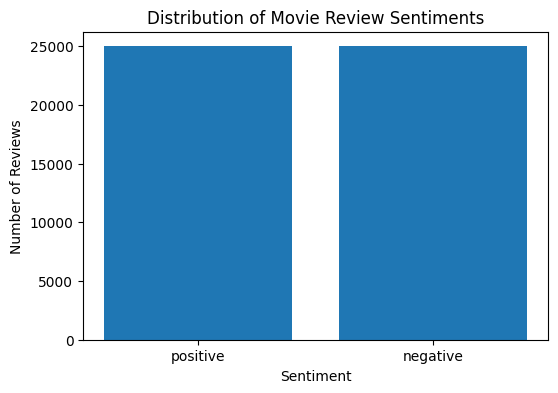

In [8]:
# Count positive and negative reviews

sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

plt.title("Distribution of Movie Review Sentiments")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

In [9]:
# Convert sentiment labels into numerical values

df["label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

# Display the result

df[["sentiment", "label"]].head()

,sentiment,label
0,positive,1
1,positive,1
2,positive,1
3,negative,0
4,positive,1


In [10]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<br\s*/?>", " ", text)

    # Remove special characters and numbers
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove multiple spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [11]:
# Apply cleaning function to every review

df["clean_review"] = df["review"].apply(clean_text)

# Compare original and cleaned review

print("Original review:")
print(df["review"].iloc[0])

print("\nCleaned review:")
print(df["clean_review"].iloc[0])

Original review:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show 

In [12]:
# Calculate number of words in each review

df["review_length"] = df["clean_review"].apply(
    lambda x: len(x.split())
)

print(df["review_length"].describe())

count    50000.000000
mean       234.187100
std        173.516096
min          6.000000
25%        128.000000
50%        176.000000
75%        284.000000
max       2494.000000
Name: review_length, dtype: float64


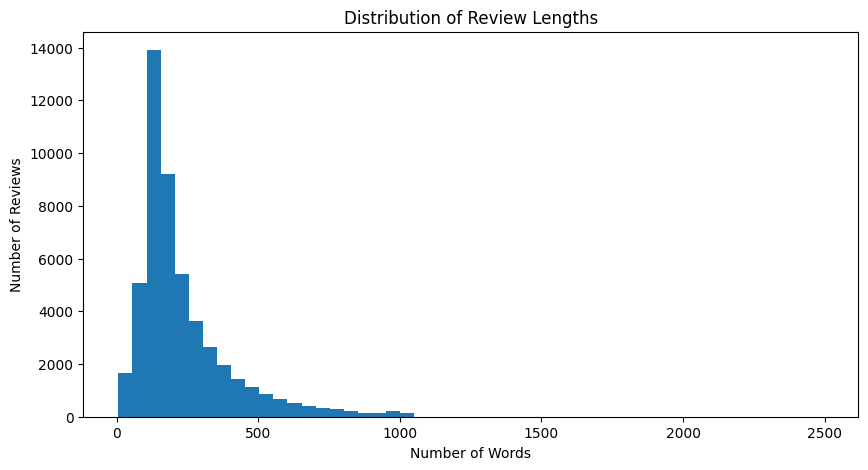

In [13]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["review_length"],
    bins=50
)

plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")

plt.show()

In [14]:
# First split:
# 80% training
# 20% temporary data

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    stratify=df["label"]
)

# Split temporary data equally:
# 10% validation
# 10% testing

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"]
)

print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Testing samples:", len(test_df))

Training samples: 40000
Validation samples: 5000
Testing samples: 5000


In [15]:
# Maximum number of words that will be kept in our vocabulary

MAX_VOCAB_SIZE = 20000

# Maximum number of words in each review

MAX_SEQUENCE_LENGTH = 200

# Size of word embeddings

EMBEDDING_DIM = 128

# Batch size for training

BATCH_SIZE = 64

print("Maximum vocabulary size:", MAX_VOCAB_SIZE)
print("Maximum sequence length:", MAX_SEQUENCE_LENGTH)
print("Embedding dimension:", EMBEDDING_DIM)
print("Batch size:", BATCH_SIZE)

Maximum vocabulary size: 20000
Maximum sequence length: 200
Embedding dimension: 128
Batch size: 64


In [16]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Create tokenizer

tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token="<OOV>"
)

# IMPORTANT:
# Fit tokenizer ONLY on training reviews
# to avoid data leakage.

tokenizer.fit_on_texts(
    train_df["clean_review"]
)

print(
    "Total words found:",
    len(tokenizer.word_index)
)

Total words found: 90522


In [17]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Convert reviews into integer sequences

X_train = tokenizer.texts_to_sequences(
    train_df["clean_review"]
)

X_val = tokenizer.texts_to_sequences(
    val_df["clean_review"]
)

X_test = tokenizer.texts_to_sequences(
    test_df["clean_review"]
)

# Display one example

print("Original review:")
print(train_df["clean_review"].iloc[0])

print("\nTokenized sequence:")
print(X_train[0][:20])

Original review:
i caught this little gem totally by accident back in or i was at a revival theatre to see two old silly sci fi movies the theatre was packed full and with no warning they showed a bunch of sci fi short spoofs to get us in the mood most were somewhat amusing but this came on and within seconds the audience was in hysterics the biggest laugh came when they showed princess laia having huge cinnamon buns instead of hair on her head she looks at the camera gives a grim smile and nods that made it even funnier you gotta see chewabacca played by what looks like a muppet it was extremely silly and stupid but i couldn t stop laughing most of the dialogue was drowned out because of all the laughter also if you know star wars pretty well it s even funnier they deliberately poke fun at some of the dialogue this really works with an audience a definite

Tokenized sequence:
[10, 1031, 11, 121, 1480, 453, 34, 1592, 145, 9, 41, 10, 14, 32, 4, 8622, 1636, 6, 66, 107]


In [18]:
# Pad or truncate sequences to MAX_SEQUENCE_LENGTH

X_train = pad_sequences(
    X_train,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_val = pad_sequences(
    X_val,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (40000, 200)
X_val shape: (5000, 200)
X_test shape: (5000, 200)


In [19]:
# Extract labels

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

print("Training labels:", y_train.shape)
print("Validation labels:", y_val.shape)
print("Testing labels:", y_test.shape)

Training labels: (40000,)
Validation labels: (5000,)
Testing labels: (5000,)


In [20]:
# Display one processed example

print("First padded sequence:")
print(X_train[0])

print("\nSequence length:")
print(len(X_train[0]))

print("\nCorresponding label:")
print(y_train[0])

First padded sequence:
[   10  1031    11   121  1480   453    34  1592   145     9    41    10
    14    32     4  8622  1636     6    66   107   159   660   854   847
    98     2  1636    14  2801   357     3    18    57  1758    33  1225
     4   735     5   854   847   333  7775     6    76   178     9     2
  1222    90    71   655  1121    19    11   377    23     3   733  1604
     2   302    14     9 16644     2  1098   419   377    52    33  1225
  2754     1   264   629     1     1   299     5  1109    23    43   404
    55   285    32     2   346   411     4  3217  1868     3 10385    12
    91     8    59  2683    21  3198    66     1   253    34    48   285
    39     4  4357     8    14   568   660     3   363    19    10   414
    22   537  1009    90     5     2   409    14  8429    44    85     5
    31     2  2127    82    45    21   120   323  1662   184    72     8
    13    59  2683    33  4296  9664   244    32    49     5     2   409
    11    63   502    18    

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout

def build_model(model_type):

    model = Sequential([
        Input(shape=(MAX_SEQUENCE_LENGTH,)),

        Embedding(
            input_dim=MAX_VOCAB_SIZE,
            output_dim=EMBEDDING_DIM,
            mask_zero=True
        )
    ])

    if model_type == "RNN":
        model.add(SimpleRNN(128))

    elif model_type == "LSTM":
        model.add(LSTM(128))

    elif model_type == "GRU":
        model.add(GRU(128))

    else:
        raise ValueError("Invalid model type")

    model.add(Dropout(0.3))
    model.add(Dense(64, activation="relu"))
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [25]:
# Build RNN
rnn_model = build_model("RNN")

# Build LSTM
lstm_model = build_model("LSTM")

# Build GRU
gru_model = build_model("GRU")

In [26]:
print("RNN MODEL")
rnn_model.summary()

print("\nLSTM MODEL")
lstm_model.summary()

print("\nGRU MODEL")
gru_model.summary()

RNN MODEL


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,601,217 (9.92 MB)

 Trainable params: 2,601,217 (9.92 MB)

...

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,393 (10.18 MB)

 Trainable params: 2,667,393 (10.18 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
print(
    "RNN parameters:",
    rnn_model.count_params()
)

print(
    "LSTM parameters:",
    lstm_model.count_params()
)

print(
    "GRU parameters:",
    gru_model.count_params()
)

RNN parameters: 2601217
LSTM parameters: 2699905
GRU parameters: 2667393


In [28]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

print("Early stopping callback created.")

Early stopping callback created.


In [29]:
EPOCHS=5

In [30]:
print("======================================")
print("Training RNN")
print("======================================")

start_time = time.time()

rnn_history = rnn_model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

rnn_training_time = time.time() - start_time

print(
    f"\nRNN training time: "
    f"{rnn_training_time:.2f} seconds"
)

Training RNN
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 21ms/step - accuracy: 0.4995 - loss: 0.7099 - val_accuracy: 0.5200 - val_loss: 0.6921
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.5181 - loss: 0.6997 - val_accuracy: 0.5248 - val_loss: 0.6872
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6150 - loss: 0.6477 - val_accuracy: 0.6802 - val_loss: 0.6124
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6981 - loss: 0.5854 - val_accuracy: 0.6868 - val_loss: 0.6375
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - accuracy: 0.7356 - loss: 0.5478 - val_accuracy: 0.7096 - val_loss: 0.5950

RNN training time: 66.91 seconds


In [31]:
print("======================================")
print("Training LSTM")
print("======================================")

start_time = time.time()

lstm_history = lstm_model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

lstm_training_time = time.time() - start_time

print(
    f"\nLSTM training time: "
    f"{lstm_training_time:.2f} seconds"
)

Training LSTM
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.7519 - loss: 0.4819 - val_accuracy: 0.8742 - val_loss: 0.3152
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.8705 - loss: 0.3135 - val_accuracy: 0.8572 - val_loss: 0.3793
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.9169 - loss: 0.2211 - val_accuracy: 0.8758 - val_loss: 0.3478

LSTM training time: 36.33 seconds


In [32]:
print("======================================")
print("Training GRU")
print("======================================")

start_time = time.time()

gru_history = gru_model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

gru_training_time = time.time() - start_time

print(
    f"\nGRU training time: "
    f"{gru_training_time:.2f} seconds"
)

Training GRU
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.7955 - loss: 0.4293 - val_accuracy: 0.8716 - val_loss: 0.3113
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.9143 - loss: 0.2233 - val_accuracy: 0.8744 - val_loss: 0.3434
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.9482 - loss: 0.1433 - val_accuracy: 0.8676 - val_loss: 0.3413

GRU training time: 31.65 seconds


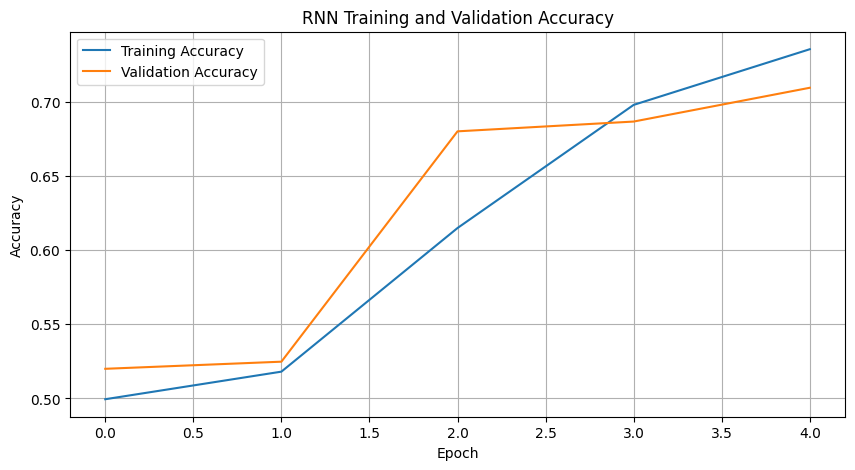

In [33]:
plt.figure(figsize=(10, 5))

plt.plot(
    rnn_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    rnn_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("RNN Training and Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

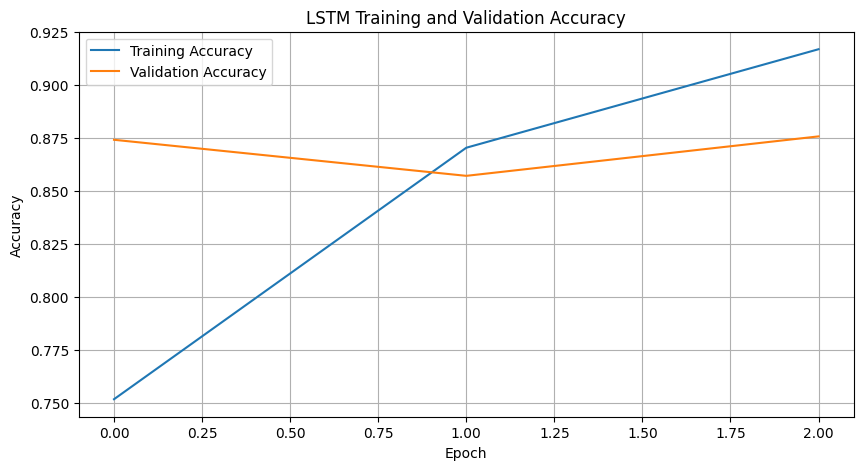

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(
    lstm_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    lstm_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("LSTM Training and Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

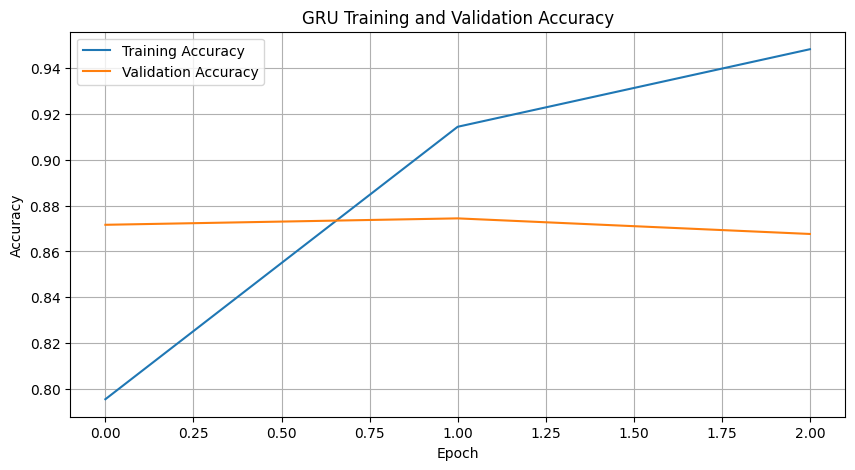

In [35]:
plt.figure(figsize=(10, 5))

plt.plot(
    gru_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    gru_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("GRU Training and Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

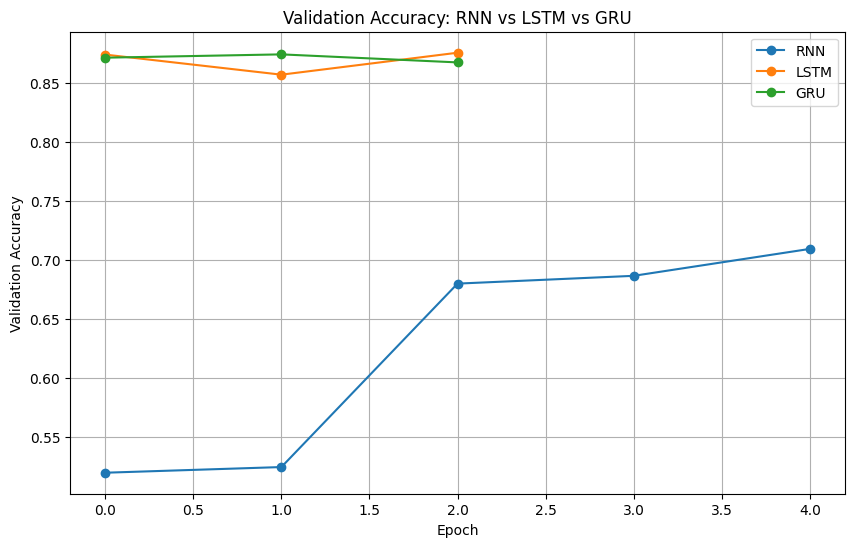

In [36]:
plt.figure(figsize=(10, 6))

plt.plot(
    rnn_history.history["val_accuracy"],
    marker="o",
    label="RNN"
)

plt.plot(
    lstm_history.history["val_accuracy"],
    marker="o",
    label="LSTM"
)

plt.plot(
    gru_history.history["val_accuracy"],
    marker="o",
    label="GRU"
)

plt.title(
    "Validation Accuracy: RNN vs LSTM vs GRU"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend()
plt.grid(True)

plt.show()

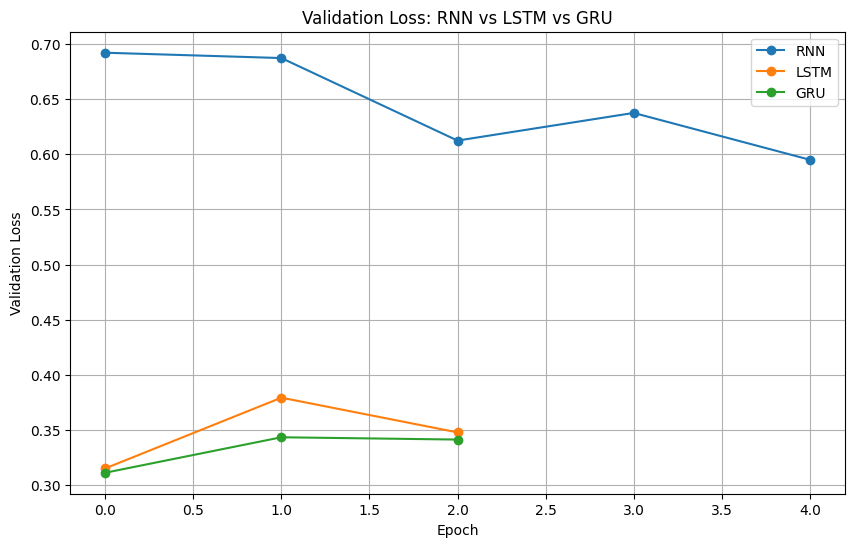

In [37]:
plt.figure(figsize=(10, 6))

plt.plot(
    rnn_history.history["val_loss"],
    marker="o",
    label="RNN"
)

plt.plot(
    lstm_history.history["val_loss"],
    marker="o",
    label="LSTM"
)

plt.plot(
    gru_history.history["val_loss"],
    marker="o",
    label="GRU"
)

plt.title(
    "Validation Loss: RNN vs LSTM vs GRU"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [38]:
lstm_test_loss, lstm_test_accuracy = lstm_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("LSTM Test Loss:", lstm_test_loss)
print("LSTM Test Accuracy:", lstm_test_accuracy)

LSTM Test Loss: 0.3274872303009033
LSTM Test Accuracy: 0.8690000176429749


In [39]:
gru_test_loss, gru_test_accuracy = gru_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("GRU Test Loss:", gru_test_loss)
print("GRU Test Accuracy:", gru_test_accuracy)

GRU Test Loss: 0.32017335295677185
GRU Test Accuracy: 0.8650000095367432


In [40]:
# Generate probabilities for all test reviews

rnn_probabilities = rnn_model.predict(
    X_test,
    verbose=0
)

lstm_probabilities = lstm_model.predict(
    X_test,
    verbose=0
)

gru_probabilities = gru_model.predict(
    X_test,
    verbose=0
)

# Convert probabilities to class labels
# Probability >= 0.5 -> Positive
# Probability < 0.5  -> Negative

rnn_predictions = (
    rnn_probabilities >= 0.5
).astype(int).flatten()

lstm_predictions = (
    lstm_probabilities >= 0.5
).astype(int).flatten()

gru_predictions = (
    gru_probabilities >= 0.5
).astype(int).flatten()

In [41]:
def calculate_metrics(y_true, y_pred):
    """
    Calculate classification metrics.
    """

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred
    )

    recall = recall_score(
        y_true,
        y_pred
    )

    f1 = f1_score(
        y_true,
        y_pred
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

In [42]:
rnn_metrics = calculate_metrics(
    y_test,
    rnn_predictions
)

lstm_metrics = calculate_metrics(
    y_test,
    lstm_predictions
)

gru_metrics = calculate_metrics(
    y_test,
    gru_predictions
)

print("RNN:")
print(rnn_metrics)

print("\nLSTM:")
print(lstm_metrics)

print("\nGRU:")
print(gru_metrics)

RNN:
{'Accuracy': 0.7018, 'Precision': 0.6987002756990941, 'Recall': 0.7096, 'F1 Score': 0.7041079579281604}

LSTM:
{'Accuracy': 0.869, 'Precision': 0.8920526986825329, 'Recall': 0.8396, 'F1 Score': 0.8650319390067999}

GRU:
{'Accuracy': 0.865, 'Precision': 0.9130828429153464, 'Recall': 0.8068, 'F1 Score': 0.8566574644298153}


In [43]:
results = pd.DataFrame({
    "RNN": rnn_metrics,
    "LSTM": lstm_metrics,
    "GRU": gru_metrics
})

results

,RNN,LSTM,GRU
Accuracy,0.701800,0.869000,0.865000
Precision,0.698700,0.892053,0.913083
Recall,0.709600,0.839600,0.806800
F1 Score,0.704108,0.865032,0.856657


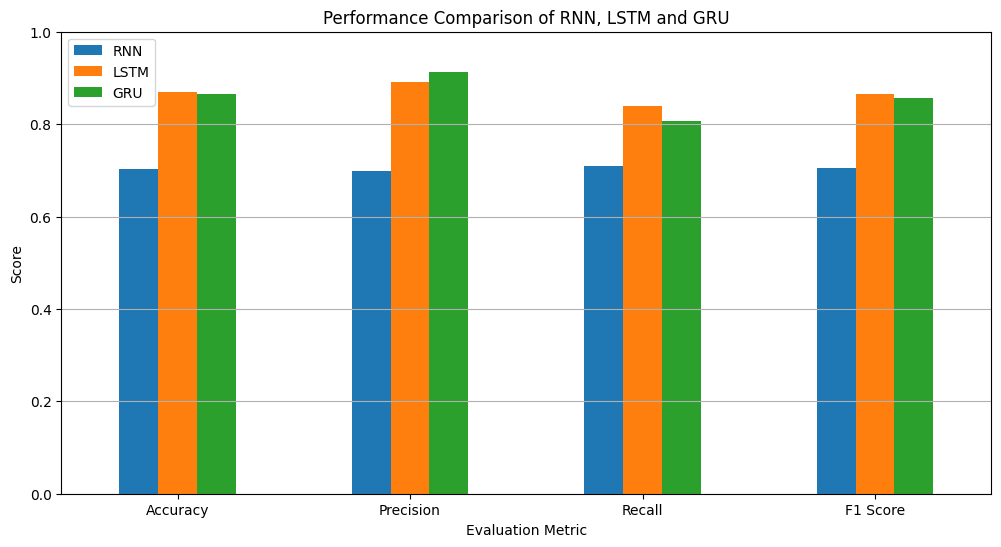

In [44]:
results.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Performance Comparison of RNN, LSTM and GRU"
)

plt.xlabel("Evaluation Metric")
plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.grid(
    axis="y"
)

plt.show()

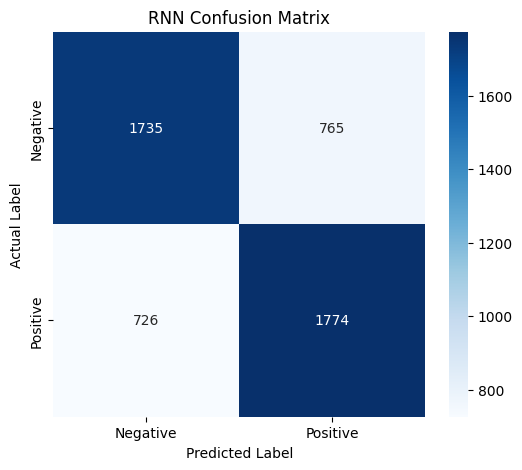

In [45]:
cm_rnn = confusion_matrix(
    y_test,
    rnn_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rnn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Negative",
        "Positive"
    ],
    yticklabels=[
        "Negative",
        "Positive"
    ]
)

plt.title("RNN Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

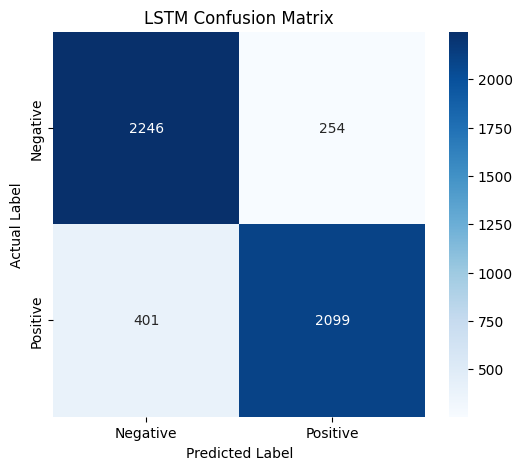

In [46]:
cm_lstm = confusion_matrix(
    y_test,
    lstm_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lstm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Negative",
        "Positive"
    ],
    yticklabels=[
        "Negative",
        "Positive"
    ]
)

plt.title("LSTM Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

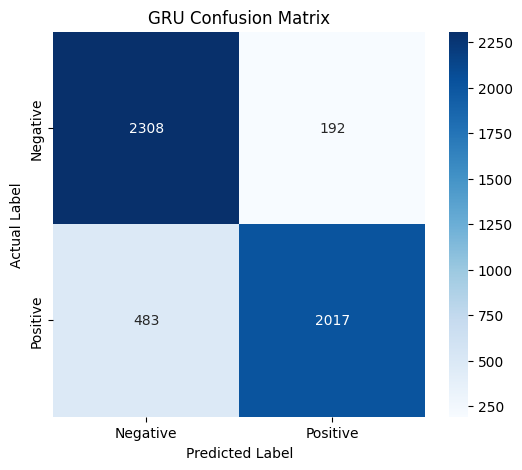

In [47]:
cm_gru = confusion_matrix(
    y_test,
    gru_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_gru,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Negative",
        "Positive"
    ],
    yticklabels=[
        "Negative",
        "Positive"
    ]
)

plt.title("GRU Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [48]:
print("RNN Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        rnn_predictions,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)

RNN Classification Report
              precision    recall  f1-score   support

    Negative       0.70      0.69      0.70      2500
    Positive       0.70      0.71      0.70      2500

    accuracy                           0.70      5000
   macro avg       0.70      0.70      0.70      5000
weighted avg       0.70      0.70      0.70      5000



In [49]:
print("LSTM Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        lstm_predictions,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)

LSTM Classification Report
              precision    recall  f1-score   support

    Negative       0.85      0.90      0.87      2500
    Positive       0.89      0.84      0.87      2500

    accuracy                           0.87      5000
   macro avg       0.87      0.87      0.87      5000
weighted avg       0.87      0.87      0.87      5000



In [50]:
print("GRU Classification Report")
print("=" * 50)

print(
    classification_report(
        y_test,
        gru_predictions,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)

GRU Classification Report
              precision    recall  f1-score   support

    Negative       0.83      0.92      0.87      2500
    Positive       0.91      0.81      0.86      2500

    accuracy                           0.86      5000
   macro avg       0.87      0.86      0.86      5000
weighted avg       0.87      0.86      0.86      5000



In [51]:
best_model = results.loc[
    "F1 Score"
].idxmax()

best_f1 = results.loc[
    "F1 Score",
    best_model
]

print(
    "Best model based on F1 Score:",
    best_model
)

print(
    "Best F1 Score:",
    round(best_f1, 4)
)

Best model based on F1 Score: LSTM
Best F1 Score: 0.865


In [52]:
def predict_sentiment(model, review):
    """
    Predict sentiment of a new movie review.
    """

    # Clean review
    cleaned_review = clean_text(review)

    # Convert text to sequence
    sequence = tokenizer.texts_to_sequences(
        [cleaned_review]
    )

    # Pad sequence
    sequence = pad_sequences(
        sequence,
        maxlen=MAX_SEQUENCE_LENGTH,
        padding="post",
        truncating="post"
    )

    # Predict probability
    probability = model.predict(
        sequence,
        verbose=0
    )[0][0]

    # Convert probability to sentiment
    if probability >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    return sentiment, probability

In [53]:
sample_review = """
This movie was absolutely fantastic.
The acting was excellent and the story was very engaging.
I really enjoyed watching it.
"""

print("Review:")
print(sample_review)

print("\nRNN:")
print(
    predict_sentiment(
        rnn_model,
        sample_review
    )
)

print("\nLSTM:")
print(
    predict_sentiment(
        lstm_model,
        sample_review
    )
)

print("\nGRU:")
print(
    predict_sentiment(
        gru_model,
        sample_review
    )
)

Review:

This movie was absolutely fantastic.
The acting was excellent and the story was very engaging.
I really enjoyed watching it.


RNN:
('Positive', np.float32(0.78241473))

LSTM:
('Positive', np.float32(0.8955839))

GRU:
('Positive', np.float32(0.9558731))


In [54]:
sample_review = """
This movie was extremely boring and disappointing.
The story was weak and the acting was terrible.
I did not enjoy watching it.
"""

print("Review:")
print(sample_review)

print("\nRNN:")
print(
    predict_sentiment(
        rnn_model,
        sample_review
    )
)

print("\nLSTM:")
print(
    predict_sentiment(
        lstm_model,
        sample_review
    )
)

print("\nGRU:")
print(
    predict_sentiment(
        gru_model,
        sample_review
    )
)

Review:

This movie was extremely boring and disappointing.
The story was weak and the acting was terrible.
I did not enjoy watching it.


RNN:
('Positive', np.float32(0.6837904))

LSTM:
('Negative', np.float32(0.025310172))

GRU:
('Negative', np.float32(0.011429567))


In [55]:
final_comparison = pd.DataFrame({

    "Model": [
        "RNN",
        "LSTM",
        "GRU"
    ],

    "Accuracy": [
        rnn_metrics["Accuracy"],
        lstm_metrics["Accuracy"],
        gru_metrics["Accuracy"]
    ],

    "Precision": [
        rnn_metrics["Precision"],
        lstm_metrics["Precision"],
        gru_metrics["Precision"]
    ],

    "Recall": [
        rnn_metrics["Recall"],
        lstm_metrics["Recall"],
        gru_metrics["Recall"]
    ],

    "F1 Score": [
        rnn_metrics["F1 Score"],
        lstm_metrics["F1 Score"],
        gru_metrics["F1 Score"]
    ],

    "Parameters": [
        rnn_model.count_params(),
        lstm_model.count_params(),
        gru_model.count_params()
    ],

    "Training Time (sec)": [
        rnn_training_time,
        lstm_training_time,
        gru_training_time
    ]
})

final_comparison

,Model,Accuracy,Precision,Recall,F1 Score,Parameters,Training Time (sec)
0,RNN,0.7018,0.698700,0.7096,0.704108,2601217,66.910403
1,LSTM,0.8690,0.892053,0.8396,0.865032,2699905,36.326509
2,GRU,0.8650,0.913083,0.8068,0.856657,2667393,31.645463
